# Section 1: Notebook Setup & Imports

This notebook runs a **400-configuration** XGBoost hyperparameter sweep on the `derived_8.4` dataset with the shared 54-feature backbone. It has **two parallel tracks**: 200 single-regime (global XGBoost) and 200 two-regime (Clustering_V0_Full_k2 MoE with per-regime feature deltas). The sweep expands the neighborhood around the `derived_8.4-eval-1.1` reference baselines (R²≈0.779 global, R²≈0.815 MoE). Parallel training defaults to **8 workers**. Model caches are CRC32-keyed for resume safety. One worker failure does not abort the whole sweep.


In [1]:
import os, sys, random, time, json, zlib, threading
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBRegressor

def find_project_root():
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for cand in candidates:
        if (cand / "data").exists() and (cand / "d_models").exists():
            return cand
    raise FileNotFoundError("Could not locate repo root containing 'data' and 'd_models'")

PROJECT_ROOT = find_project_root()
print(f"Project root found: {PROJECT_ROOT}")

sys_path_root = str(PROJECT_ROOT)
if sys_path_root not in sys.path:
    sys.path.append(sys_path_root)

out_dir = PROJECT_ROOT / "notebooks/experiment/derived_8.4-hyperparameters-1.0"
out_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {out_dir}")

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"Random seed set to {SEED}")

PARALLEL_WORKERS = int(os.environ.get("XGB_PARALLEL_WORKERS", "8"))
print(f"Parallel workers: {PARALLEL_WORKERS} (override with XGB_PARALLEL_WORKERS)")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

try:
    dummy = xgb.XGBRegressor(n_estimators=1, device="cuda")
    dummy.fit(np.array([[1.0]]), np.array([1.0]))
    XGB_DEVICE = "cuda"
    print("XGBoost CUDA support verified and enabled.")
except Exception as e:
    XGB_DEVICE = "cpu"
    print(f"XGBoost CUDA test failed ({e}). Falling back to CPU.")

print("Setup complete. Using device:", XGB_DEVICE)

Project root found: /scratch/user/u.rp352032/MDR-Project
Output directory: /scratch/user/u.rp352032/MDR-Project/notebooks/experiment/derived_8.4-hyperparameters-1.0
Random seed set to 42
Parallel workers: 8 (override with XGB_PARALLEL_WORKERS)


XGBoost CUDA support verified and enabled.
Setup complete. Using device: cuda


# Section 2: Data Loading & Preprocessing

Load the derived_8.4 train / val / test splits, parse dates, and form the trainval matrix used for all boosters. Evaluation remains on the held-out test split. The derived_8.4 dataset has ~21k rows across 7 Washington stations (CayusePass, Darrington, Paradise, Quinault, SourdoughGulch, Spokane) — about 2/3 the size of derived_8.2 with fewer impossible stations removed.


In [2]:
TRAIN_PATH = PROJECT_ROOT / "data/splits/derived_8.4/train.csv"
VAL_PATH = PROJECT_ROOT / "data/splits/derived_8.4/val.csv"
TEST_PATH = PROJECT_ROOT / "data/splits/derived_8.4/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Dataset splits loaded:")
print(f"  train: {train_df.shape}")
print(f"  val:   {val_df.shape}")
print(f"  test:  {test_df.shape}")

for df in [train_df, val_df, test_df]:
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month.astype(int)
    df["year"] = df["date"].dt.year.astype(float)

trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
print(f"  trainval (concatenated): {trainval_df.shape}")


Dataset splits loaded:
  train: (9803, 499)
  val:   (4805, 499)
  test:  (6620, 499)
  trainval (concatenated): (14608, 500)


# Section 3: Feature Set Definitions


In [3]:
import importlib.util

# Load V0 features from derived_8.4 metadata (used for KMeans clustering router)
metadata_path = PROJECT_ROOT / "data/splits/derived_8.4/dataset_metadata.py"
spec = importlib.util.spec_from_file_location("derived_84_metadata", metadata_path)
derived_84_metadata = importlib.util.module_from_spec(spec)
spec.loader.exec_module(derived_84_metadata)
V0_FEATURES = list(derived_84_metadata.OVERALL_SELECTED_FEATURES_V0)

# Shared 54-feature backbone from derived_8.4-eval-1.1 (best performing global feature set)
SHARED_BACKBONE_54 = [
    "precip_mm",
    "s2_b4",
    "s2_b8",
    "SMAP_sm_pm_interp",
    "D_sin_DOY",
    "D_cos_DOY",
    "E_SAR_ratio",
    "G_API",
    "G_DSLR",
    "G_rain_sum_3d",
    "G_rain_sum_7d",
    "SMAP_sm_pm_interp_lag7",
    "SMAP_sm_pm_interp_lag30",
    "SMAP_sm_pm_interp_rollrange7",
    "SMAP_sm_pm_interp_rollmean30",
    "SMAP_sm_pm_interp_rollrange30",
    "SMAP_sm_interp_rollrange7",
    "SMAP_ampm_diff_interp",
    "V_rollrng_G_API_kobs7",
    "V_rollmax_F_NDMI_kobs30",
    "A_d_E_SAR_ratio_kobs30",
    "V_rollmax_E_SAR_ratio_kobs7",
    "V_rollmin_E_SAR_ratio_kobs30",
    "V_rollmax_E_SAR_ratio_kobs30",
    "V_rollmin_LST_modis_kobs30",
    "V_ema_LST_modis_kobs30",
    "V_rollmax_F_NDVI_kobs14",
    "V_rollmax_F_NDVI_kobs30",
    "V_ema_F_NDVI_kobs30",
    "C_lag_F_NDVI_kobs30",
    "A_grad_E_SAR_diff_kobs30",
    "V_rollmax_E_SAR_diff_kobs14",
    "V_rollrng_E_SAR_diff_kobs30",
    "V_rollmax_E_SAR_diff_kobs30",
    "A_grad_s2_b11_kobs30",
    "V_rollrng_s2_b11_kobs30",
    "V_rollmin_s2_b11_kobs30",
    "V_rollmin_s2_b12_kobs30",
    "A_d_SMAP_sm_interp_kobs30",
    "V_rollmin_SMAP_sm_interp_kobs14",
    "V_rollmin_SMAP_sm_interp_kobs30",
    "E_rough_s1_vh_kobs14",
    "J_aspect_deg",
    "J_bio_bio02",
    "J_bio_bio13",
    "J_lc_code",
    "J_soil_texture_usda_b0",
    "sin_year",
    "cos_year",
    "SMAP_x_year",
    "D_z_F_NDMI",
    "D_z_LST_modis",
    "D_fft_dom_LST_modis_kobs30",
    "D_fft_ent_LST_modis_kobs30",
]

# Per-regime additions for Clustering_V0_Full_k2 winner (c0=0, c1=10) from derived_8.4-eval-1.1
CLUSTER_1_ADDITIONS = [
    "V_rollmin_F_NDMI_kobs30",
    "V_rollmean_G_API_kobs14",
    "lia_mean_asc_deg",
    "J_bio_bio04",
    "DOY",
    "SMAP_sm_am_interp",
    "J_bio_bio07",
    "SMAP_sm_am_interp_lag1",
    "C_lag_F_NDMI_kobs30",
    "SMAP_sm_pm_interp_lag1",
]

TARGET_COL = "soil_moisture_5cm"

# Reference metrics from derived_8.4-eval-1.1 for comparison
EVAL_11_GLOBAL_BASELINE_R2 = 0.77923   # Global Single Model (54 Backbone)
EVAL_11_CLUSTERING_WINNER_R2 = 0.81496 # Clustering_V0_Full_k2 (c0=0, c1=10)

print(f"V0 features (for clustering): {len(V0_FEATURES)}")
print(f"Shared backbone 54: {len(SHARED_BACKBONE_54)}")
print(f"Cluster 1 additions: {len(CLUSTER_1_ADDITIONS)}")
print(f"8.4-eval global baseline R²: {EVAL_11_GLOBAL_BASELINE_R2:.5f}")
print(f"8.4-eval Clustering winner R²: {EVAL_11_CLUSTERING_WINNER_R2:.5f}")


V0 features (for clustering): 50
Shared backbone 54: 54
Cluster 1 additions: 10
8.4-eval global baseline R²: 0.77923
8.4-eval Clustering winner R²: 0.81496


# Section 4: 400 Hyperparameter Configurations (200 Single-Regime + 200 Two-Regime)


In [4]:
# Lean estimator schedule — fewer steps than 1.5 since derived_8.4 is smaller and XGBoost converges early
LEAN_EST = {
    0.003: 1500,
    0.004: 1300,
    0.005: 1000,
    0.006: 900,
    0.007: 800,
    0.008: 750,
    0.01: 500,
    0.012: 400,
}

def lean_estimators(lr: float) -> int:
    if lr in LEAN_EST:
        return LEAN_EST[lr]
    keys = sorted(LEAN_EST.keys())
    nearest = min(keys, key=lambda k: abs(k - lr))
    return LEAN_EST[nearest]

# Build both tracks
SINGLE_MODELS_CONFIG = []
TWO_REGIME_MODELS_CONFIG = []
MODELS_CONFIG = []  # Combined list

# =============== SINGLE REGIME TRACK (200 configs) ===============
# Uses shared_backbone_54 features, trains one global XGBoost

# --- Group SR — References (6) ---
SINGLE_MODELS_CONFIG.extend([
    {"id": 0, "group": "SR", "name": "SR 8.4-eval Baseline (d9 LR=0.005 MCW=8 L2=0.75 L1=0.03 Est=2500)",
     "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
     "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
     "learning_rate": 0.005, "n_estimators": 2500,
     "track": "single"},
    {"id": 1, "group": "SR", "name": "SR Lean Ref (d9 LR=0.005 MCW=8 L2=0.75 L1=0.03 Est=1000)",
     "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
     "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
     "learning_rate": 0.005, "n_estimators": 1000,
     "track": "single"},
    {"id": 2, "group": "SR", "name": "SR 1.5 SOTA Params (d9 LR=0.005 MCW=8 L2=0.75 L1=0.03 Est=2500)",
     "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
     "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
     "learning_rate": 0.005, "n_estimators": 2500,
     "track": "single"},
    {"id": 3, "group": "SR", "name": "SR MAE Objective",
     "objective": "reg:absoluteerror", "max_depth": 9, "min_child_weight": 8,
     "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
     "learning_rate": 0.005, "n_estimators": 1000,
     "track": "single"},
    {"id": 4, "group": "SR", "name": "SR MSE Objective Est=1000",
     "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
     "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
     "learning_rate": 0.005, "n_estimators": 1000,
     "track": "single"},
    {"id": 5, "group": "SR", "name": "SR MAPE Objective",
     "objective": "reg:absoluteerror", "max_depth": 9, "min_child_weight": 8,
     "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
     "learning_rate": 0.005, "n_estimators": 1000,
     "track": "single"},
])

# --- Group SA — Depth x LR x MCW (60) ---
sid = 6
for depth in [8, 9, 10]:
    for lr in [0.003, 0.005, 0.008, 0.01]:
        for mcw in [4, 6, 8, 10, 15]:
            est = lean_estimators(lr)
            SINGLE_MODELS_CONFIG.append({
                "id": sid, "group": "SA", "track": "single",
                "name": f"SA d={depth} LR={lr} MCW={mcw} Est={est}",
                "objective": "reg:squarederror", "max_depth": depth,
                "min_child_weight": mcw, "reg_lambda": 0.75, "reg_alpha": 0.03,
                "subsample": 0.9, "colsample_bytree": 0.8,
                "learning_rate": lr, "n_estimators": est,
            })
            sid += 1

# --- Group SB — L2 x L1 (48) ---
# L2 main grid (42): L2 x L1 wide
for l2 in [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]:
    for l1 in [0.0, 0.01, 0.03, 0.05, 0.08, 0.1]:
        SINGLE_MODELS_CONFIG.append({
            "id": sid, "group": "SB", "track": "single",
            "name": f"SB L2={l2} L1={l1} (d9 LR0.005 MCW8)",
            "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
            "reg_lambda": l2, "reg_alpha": l1, "subsample": 0.9, "colsample_bytree": 0.8,
            "learning_rate": 0.005, "n_estimators": 1000,
        })
        sid += 1
# Tight plateau (6): fine around 1.5 winner L2=0.75 L1=0.03
for l2 in [0.65, 0.9, 1.25]:
    for l1 in [0.02, 0.04]:
        SINGLE_MODELS_CONFIG.append({
            "id": sid, "group": "SB", "track": "single",
            "name": f"SB L2={l2} L1={l1} (d9 LR0.005 MCW8 plateau)",
            "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
            "reg_lambda": l2, "reg_alpha": l1, "subsample": 0.9, "colsample_bytree": 0.8,
            "learning_rate": 0.005, "n_estimators": 1000,
        })
        sid += 1

# --- Group SC — Sampling (24) ---
for sub in [0.8, 0.85, 0.9, 0.95, 1.0]:
    for col in [0.7, 0.75, 0.8, 0.85, 0.9]:
        # Skip duplicate of the baseline config (R1: sub=0.9 col=0.8 at d9 LR0.005)
        if sub == 0.9 and col == 0.8:
            continue
        SINGLE_MODELS_CONFIG.append({
            "id": sid, "group": "SC", "track": "single",
            "name": f"SC sub={sub} col={col} (d9 LR0.005 MCW8)",
            "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
            "reg_lambda": 0.75, "reg_alpha": 0.03,
            "subsample": sub, "colsample_bytree": col,
            "learning_rate": 0.005, "n_estimators": 1000,
        })
        sid += 1

# --- Group SD — Estimator budget (24) ---
for est in [500, 800, 1000, 1500, 2000, 3000]:
    for depth in [9, 10]:
        for lr in [0.005, 0.008]:
            SINGLE_MODELS_CONFIG.append({
                "id": sid, "group": "SD", "track": "single",
                "name": f"SD d={depth} LR={lr} Est={est} MCW=8",
                "objective": "reg:squarederror", "max_depth": depth, "min_child_weight": 8,
                "reg_lambda": 0.75, "reg_alpha": 0.03,
                "subsample": 0.9, "colsample_bytree": 0.8,
                "learning_rate": lr, "n_estimators": est,
            })
            sid += 1

# --- Group SE — Probes & champions (38) ---
# SE1: gamma (5)
for gamma in [0.0, 0.1, 0.5, 1.0, 2.0]:
    SINGLE_MODELS_CONFIG.append({
        "id": sid, "group": "SE", "track": "single",
        "name": f"SE Gamma={gamma} (d9 LR0.005 MCW8)",
        "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
        "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
        "learning_rate": 0.005, "n_estimators": 1000, "gamma": gamma,
    })
    sid += 1

# SE2: max_bin (3)
for max_bin in [128, 256, 512]:
    SINGLE_MODELS_CONFIG.append({
        "id": sid, "group": "SE", "track": "single",
        "name": f"SE Bin={max_bin} (d9 LR0.005 MCW8)",
        "objective": "reg:squarederror", "max_bin": max_bin,
        "max_depth": 9, "min_child_weight": 8,
        "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
        "learning_rate": 0.005, "n_estimators": 1000,
    })
    sid += 1

# SE3: lossguide (4)
for leaves in [63, 127, 255, 511]:
    SINGLE_MODELS_CONFIG.append({
        "id": sid, "group": "SE", "track": "single",
        "name": f"SE Leaf={leaves} (d9 LR0.005 MCW8)",
        "objective": "reg:squarederror", "grow_policy": "lossguide",
        "max_leaves": leaves, "max_depth": 9, "min_child_weight": 8,
        "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
        "learning_rate": 0.005, "n_estimators": 1000,
    })
    sid += 1

# SE4: depth-11 probes (4)
for lr in [0.003, 0.005]:
    for mcw in [8, 12]:
        est = lean_estimators(lr)
        SINGLE_MODELS_CONFIG.append({
            "id": sid, "group": "SE", "track": "single",
            "name": f"SE d=11 LR={lr} MCW={mcw} Est={est}",
            "objective": "reg:squarederror", "max_depth": 11, "min_child_weight": mcw,
            "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
            "learning_rate": lr, "n_estimators": est,
        })
        sid += 1

# SE5: plateau polish — MCW x L2 x L1 fine grid (8)
for mcw in [5, 7]:
    for l2 in [0.65, 0.9]:
        for l1 in [0.02, 0.04]:
            SINGLE_MODELS_CONFIG.append({
                "id": sid, "group": "SE", "track": "single",
                "name": f"SE MCW={mcw} L2={l2} L1={l1} (d9 LR0.005)",
                "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": mcw,
                "reg_lambda": l2, "reg_alpha": l1, "subsample": 0.9, "colsample_bytree": 0.8,
                "learning_rate": 0.005, "n_estimators": 1000,
            })
            sid += 1

# SE6: champion combos (8)
champion_specs_single = [
    {"name": "SE Best L2=0.75 L1=0.03 MCW=6", "min_child_weight": 6, "reg_lambda": 0.75, "reg_alpha": 0.03},
    {"name": "SE Best L2=0.75 L1=0.03 MCW=10", "min_child_weight": 10, "reg_lambda": 0.75, "reg_alpha": 0.03},
    {"name": "SE Best L2=1.0 L1=0.03 MCW=8", "min_child_weight": 8, "reg_lambda": 1.0, "reg_alpha": 0.03},
    {"name": "SE Best L2=0.5 L1=0.05 MCW=8", "min_child_weight": 8, "reg_lambda": 0.5, "reg_alpha": 0.05},
    {"name": "SE d=8 LR=0.005 MCW=8 L2=0.75 L1=0.03", "max_depth": 8, "min_child_weight": 8, "reg_lambda": 0.75, "reg_alpha": 0.03},
    {"name": "SE d=10 LR=0.005 MCW=8 L2=0.75 L1=0.03", "max_depth": 10, "min_child_weight": 8, "reg_lambda": 0.75, "reg_alpha": 0.03},
    {"name": "SE sub=0.95 col=0.85 d9 LR0.005 MCW8", "min_child_weight": 8, "subsample": 0.95, "colsample_bytree": 0.85, "reg_lambda": 0.75, "reg_alpha": 0.03},
    {"name": "SE Est=2000 d9 LR=0.005 MCW=8", "min_child_weight": 8, "reg_lambda": 0.75, "reg_alpha": 0.03, "n_estimators": 2000},
]
for spec in champion_specs_single:
    cfg = {"id": sid, "group": "SE", "track": "single",
           "objective": "reg:squarederror", "max_depth": 9,
           "subsample": 0.9, "colsample_bytree": 0.8,
           "learning_rate": 0.005, "n_estimators": 1000}
    cfg.update(spec)
    SINGLE_MODELS_CONFIG.append(cfg)
    sid += 1

# SE7: depth-8 with slightly different LR (2 more)
for lr in [0.003, 0.008]:
    est = lean_estimators(lr)
    SINGLE_MODELS_CONFIG.append({
        "id": sid, "group": "SE", "track": "single",
        "name": f"SE d=8 LR={lr} MCW=8 L2=0.75 L1=0.03 Est={est}",
        "objective": "reg:squarederror", "max_depth": 8, "min_child_weight": 8,
        "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
        "learning_rate": lr, "n_estimators": est,
    })
    sid += 1

# SE8: extra plateau probes (4) to fill to 38
for mcw in [6, 9]:
    for l2 in [0.5, 1.25]:
        SINGLE_MODELS_CONFIG.append({
            "id": sid, "group": "SE", "track": "single",
            "name": f"SE MCW={mcw} L2={l2} L1=0.03 (d9 LR0.005)",
            "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": mcw,
            "reg_lambda": l2, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
            "learning_rate": 0.005, "n_estimators": 1000,
        })
        sid += 1

print(f"Single-regime configs: {len(SINGLE_MODELS_CONFIG)}")

# =============== TWO-REGIME TRACK (200 configs) ===============
# Uses Clustering_V0_Full_k2 routing (KMeans on V0 features)
# Cluster 0: shared_backbone_54, Cluster 1: shared_backbone_54 + CLUSTER_1_ADDITIONS

# --- Group TR — References (6) ---
TR_START = sid
TWO_REGIME_MODELS_CONFIG.extend([
    {"id": sid, "group": "TR", "name": "TR 8.4-eval Baseline (d9 LR=0.005 MCW=8 L2=0.75 L1=0.03 Est=2500)",
     "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
     "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
     "learning_rate": 0.005, "n_estimators": 2500,
     "track": "two_regime", "routing": "Clustering_V0_Full_k2"},
    {"id": sid+1, "group": "TR", "name": "TR Lean Ref (d9 LR=0.005 MCW=8 L2=0.75 L1=0.03 Est=1000)",
     "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
     "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
     "learning_rate": 0.005, "n_estimators": 1000,
     "track": "two_regime", "routing": "Clustering_V0_Full_k2"},
    {"id": sid+2, "group": "TR", "name": "TR 1.5 SOTA Params (d9 LR=0.005 MCW=8 L2=0.75 L1=0.03 Est=2500)",
     "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
     "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
     "learning_rate": 0.005, "n_estimators": 2500,
     "track": "two_regime", "routing": "Clustering_V0_Full_k2"},
    {"id": sid+3, "group": "TR", "name": "TR MAE Objective",
     "objective": "reg:absoluteerror", "max_depth": 9, "min_child_weight": 8,
     "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
     "learning_rate": 0.005, "n_estimators": 1000,
     "track": "two_regime", "routing": "Clustering_V0_Full_k2"},
    {"id": sid+4, "group": "TR", "name": "TR MSE Objective Est=1000",
     "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
     "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
     "learning_rate": 0.005, "n_estimators": 1000,
     "track": "two_regime", "routing": "Clustering_V0_Full_k2"},
    {"id": sid+5, "group": "TR", "name": "TR MAPE Objective",
     "objective": "reg:absoluteerror", "max_depth": 9, "min_child_weight": 8,
     "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
     "learning_rate": 0.005, "n_estimators": 1000,
     "track": "two_regime", "routing": "Clustering_V0_Full_k2"},
])
sid += 6

# --- Group TA — Depth x LR x MCW (60) ---
for depth in [8, 9, 10]:
    for lr in [0.003, 0.005, 0.008, 0.01]:
        for mcw in [4, 6, 8, 10, 15]:
            est = lean_estimators(lr)
            TWO_REGIME_MODELS_CONFIG.append({
                "id": sid, "group": "TA", "track": "two_regime", "routing": "Clustering_V0_Full_k2",
                "name": f"TA d={depth} LR={lr} MCW={mcw} Est={est}",
                "objective": "reg:squarederror", "max_depth": depth,
                "min_child_weight": mcw, "reg_lambda": 0.75, "reg_alpha": 0.03,
                "subsample": 0.9, "colsample_bytree": 0.8,
                "learning_rate": lr, "n_estimators": est,
            })
            sid += 1

# --- Group TB — L2 x L1 (48) ---
for l2 in [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]:
    for l1 in [0.0, 0.01, 0.03, 0.05, 0.08, 0.1]:
        TWO_REGIME_MODELS_CONFIG.append({
            "id": sid, "group": "TB", "track": "two_regime", "routing": "Clustering_V0_Full_k2",
            "name": f"TB L2={l2} L1={l1} (d9 LR0.005 MCW8)",
            "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
            "reg_lambda": l2, "reg_alpha": l1, "subsample": 0.9, "colsample_bytree": 0.8,
            "learning_rate": 0.005, "n_estimators": 1000,
        })
        sid += 1
for l2 in [0.65, 0.9, 1.25]:
    for l1 in [0.02, 0.04]:
        TWO_REGIME_MODELS_CONFIG.append({
            "id": sid, "group": "TB", "track": "two_regime", "routing": "Clustering_V0_Full_k2",
            "name": f"TB L2={l2} L1={l1} (d9 LR0.005 MCW8 plateau)",
            "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
            "reg_lambda": l2, "reg_alpha": l1, "subsample": 0.9, "colsample_bytree": 0.8,
            "learning_rate": 0.005, "n_estimators": 1000,
        })
        sid += 1

# --- Group TC — Sampling (24) ---
for sub in [0.8, 0.85, 0.9, 0.95, 1.0]:
    for col in [0.7, 0.75, 0.8, 0.85, 0.9]:
        if sub == 0.9 and col == 0.8:
            continue
        TWO_REGIME_MODELS_CONFIG.append({
            "id": sid, "group": "TC", "track": "two_regime", "routing": "Clustering_V0_Full_k2",
            "name": f"TC sub={sub} col={col} (d9 LR0.005 MCW8)",
            "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
            "reg_lambda": 0.75, "reg_alpha": 0.03,
            "subsample": sub, "colsample_bytree": col,
            "learning_rate": 0.005, "n_estimators": 1000,
        })
        sid += 1

# --- Group TD — Estimator budget (24) ---
for est in [500, 800, 1000, 1500, 2000, 3000]:
    for depth in [9, 10]:
        for lr in [0.005, 0.008]:
            TWO_REGIME_MODELS_CONFIG.append({
                "id": sid, "group": "TD", "track": "two_regime", "routing": "Clustering_V0_Full_k2",
                "name": f"TD d={depth} LR={lr} Est={est} MCW=8",
                "objective": "reg:squarederror", "max_depth": depth, "min_child_weight": 8,
                "reg_lambda": 0.75, "reg_alpha": 0.03,
                "subsample": 0.9, "colsample_bytree": 0.8,
                "learning_rate": lr, "n_estimators": est,
            })
            sid += 1

# --- Group TE — Probes & champions (38) ---
for gamma in [0.0, 0.1, 0.5, 1.0, 2.0]:
    TWO_REGIME_MODELS_CONFIG.append({
        "id": sid, "group": "TE", "track": "two_regime", "routing": "Clustering_V0_Full_k2",
        "name": f"TE Gamma={gamma} (d9 LR0.005 MCW8)",
        "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": 8,
        "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
        "learning_rate": 0.005, "n_estimators": 1000, "gamma": gamma,
    })
    sid += 1
for max_bin in [128, 256, 512]:
    TWO_REGIME_MODELS_CONFIG.append({
        "id": sid, "group": "TE", "track": "two_regime", "routing": "Clustering_V0_Full_k2",
        "name": f"TE Bin={max_bin} (d9 LR0.005 MCW8)",
        "objective": "reg:squarederror", "max_bin": max_bin,
        "max_depth": 9, "min_child_weight": 8,
        "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
        "learning_rate": 0.005, "n_estimators": 1000,
    })
    sid += 1
for leaves in [63, 127, 255, 511]:
    TWO_REGIME_MODELS_CONFIG.append({
        "id": sid, "group": "TE", "track": "two_regime", "routing": "Clustering_V0_Full_k2",
        "name": f"TE Leaf={leaves} (d9 LR0.005 MCW8)",
        "objective": "reg:squarederror", "grow_policy": "lossguide",
        "max_leaves": leaves, "max_depth": 9, "min_child_weight": 8,
        "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
        "learning_rate": 0.005, "n_estimators": 1000,
    })
    sid += 1
for lr in [0.003, 0.005]:
    for mcw in [8, 12]:
        est = lean_estimators(lr)
        TWO_REGIME_MODELS_CONFIG.append({
            "id": sid, "group": "TE", "track": "two_regime", "routing": "Clustering_V0_Full_k2",
            "name": f"TE d=11 LR={lr} MCW={mcw} Est={est}",
            "objective": "reg:squarederror", "max_depth": 11, "min_child_weight": mcw,
            "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
            "learning_rate": lr, "n_estimators": est,
        })
        sid += 1
for mcw in [5, 7]:
    for l2 in [0.65, 0.9]:
        for l1 in [0.02, 0.04]:
            TWO_REGIME_MODELS_CONFIG.append({
                "id": sid, "group": "TE", "track": "two_regime", "routing": "Clustering_V0_Full_k2",
                "name": f"TE MCW={mcw} L2={l2} L1={l1} (d9 LR0.005)",
                "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": mcw,
                "reg_lambda": l2, "reg_alpha": l1, "subsample": 0.9, "colsample_bytree": 0.8,
                "learning_rate": 0.005, "n_estimators": 1000,
            })
            sid += 1
# TE champions (same as single regime, adapted)
champion_specs_two = [
    {"name": "TE Best L2=0.75 L1=0.03 MCW=6", "min_child_weight": 6, "reg_lambda": 0.75, "reg_alpha": 0.03},
    {"name": "TE Best L2=0.75 L1=0.03 MCW=10", "min_child_weight": 10, "reg_lambda": 0.75, "reg_alpha": 0.03},
    {"name": "TE Best L2=1.0 L1=0.03 MCW=8", "min_child_weight": 8, "reg_lambda": 1.0, "reg_alpha": 0.03},
    {"name": "TE Best L2=0.5 L1=0.05 MCW=8", "min_child_weight": 8, "reg_lambda": 0.5, "reg_alpha": 0.05},
    {"name": "TE d=8 LR=0.005 MCW=8 L2=0.75 L1=0.03", "max_depth": 8, "min_child_weight": 8, "reg_lambda": 0.75, "reg_alpha": 0.03},
    {"name": "TE d=10 LR=0.005 MCW=8 L2=0.75 L1=0.03", "max_depth": 10, "min_child_weight": 8, "reg_lambda": 0.75, "reg_alpha": 0.03},
    {"name": "TE sub=0.95 col=0.85 d9 LR0.005 MCW8", "min_child_weight": 8, "subsample": 0.95, "colsample_bytree": 0.85, "reg_lambda": 0.75, "reg_alpha": 0.03},
    {"name": "TE Est=2000 d9 LR=0.005 MCW=8", "min_child_weight": 8, "reg_lambda": 0.75, "reg_alpha": 0.03, "n_estimators": 2000},
]
for spec in champion_specs_two:
    cfg = {"id": sid, "group": "TE", "track": "two_regime", "routing": "Clustering_V0_Full_k2",
           "objective": "reg:squarederror", "max_depth": 9,
           "subsample": 0.9, "colsample_bytree": 0.8,
           "learning_rate": 0.005, "n_estimators": 1000}
    cfg.update(spec)
    TWO_REGIME_MODELS_CONFIG.append(cfg)
    sid += 1
for lr in [0.003, 0.008]:
    est = lean_estimators(lr)
    TWO_REGIME_MODELS_CONFIG.append({
        "id": sid, "group": "TE", "track": "two_regime", "routing": "Clustering_V0_Full_k2",
        "name": f"TE d=8 LR={lr} MCW=8 L2=0.75 L1=0.03 Est={est}",
        "objective": "reg:squarederror", "max_depth": 8, "min_child_weight": 8,
        "reg_lambda": 0.75, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
        "learning_rate": lr, "n_estimators": est,
    })
    sid += 1
for mcw in [6, 9]:
    for l2 in [0.5, 1.25]:
        TWO_REGIME_MODELS_CONFIG.append({
            "id": sid, "group": "TE", "track": "two_regime", "routing": "Clustering_V0_Full_k2",
            "name": f"TE MCW={mcw} L2={l2} L1=0.03 (d9 LR0.005)",
            "objective": "reg:squarederror", "max_depth": 9, "min_child_weight": mcw,
            "reg_lambda": l2, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8,
            "learning_rate": 0.005, "n_estimators": 1000,
        })
        sid += 1

print(f"Two-regime configs: {len(TWO_REGIME_MODELS_CONFIG)}")

# Combine
MODELS_CONFIG = SINGLE_MODELS_CONFIG + TWO_REGIME_MODELS_CONFIG

# Validation
EXPECTED_SINGLE_GROUPS = Counter({"SR": 6, "SA": 60, "SB": 48, "SC": 24, "SD": 24, "SE": 38})
EXPECTED_TWO_GROUPS = Counter({"TR": 6, "TA": 60, "TB": 48, "TC": 24, "TD": 24, "TE": 38})
single_counts = Counter(c["group"] for c in SINGLE_MODELS_CONFIG)
two_counts = Counter(c["group"] for c in TWO_REGIME_MODELS_CONFIG)
ids = [c["id"] for c in MODELS_CONFIG]

print(f"\nSingle-regime group counts: {dict(single_counts)}")
assert single_counts == EXPECTED_SINGLE_GROUPS, f"Single group mismatch: {single_counts} vs {EXPECTED_SINGLE_GROUPS}"
print(f"Two-regime group counts: {dict(two_counts)}")
assert two_counts == EXPECTED_TWO_GROUPS, f"Two group mismatch: {two_counts} vs {EXPECTED_TWO_GROUPS}"
assert len(SINGLE_MODELS_CONFIG) == 200, f"Expected 200 single configs, got {len(SINGLE_MODELS_CONFIG)}"
assert len(TWO_REGIME_MODELS_CONFIG) == 200, f"Expected 200 two-regime configs, got {len(TWO_REGIME_MODELS_CONFIG)}"
assert len(MODELS_CONFIG) == 400, f"Expected 400 total configs, got {len(MODELS_CONFIG)}"
assert len(ids) == len(set(ids)), "Duplicate model ids"
assert ids == list(range(400)), "Model ids must be contiguous 0..399"

print(f"\nTotal model configurations: {len(MODELS_CONFIG)}")
print(f"  Single-regime: {len(SINGLE_MODELS_CONFIG)}")
print(f"  Two-regime:    {len(TWO_REGIME_MODELS_CONFIG)}")
print(f"  ID range: 0..{len(MODELS_CONFIG) - 1}")


Single-regime configs: 200
Two-regime configs: 200

Single-regime group counts: {'SR': 6, 'SA': 60, 'SB': 48, 'SC': 24, 'SD': 24, 'SE': 38}
Two-regime group counts: {'TR': 6, 'TA': 60, 'TB': 48, 'TC': 24, 'TD': 24, 'TE': 38}

Total model configurations: 400
  Single-regime: 200
  Two-regime:    200
  ID range: 0..399


# Section 5: Parallel Training Loop — Single-Regime & Two-Regime Tracks

Train 400 total models (200 single-regime + 200 two-regime Clustering_V0_Full_k2 MoE) with a thread pool (default 8 workers). Each model is CRC32-cached for resume safety. Single-regime trains one global XGBoost on shared_backbone_54. Two-regime fits a KMeans(V0) router, then trains 2 per-cluster experts. Worker exceptions are caught per-future so one failure does not abort the sweep.


In [5]:
y_trainval = np.asarray(trainval_df[TARGET_COL]).ravel()
y_test = np.asarray(test_df[TARGET_COL]).ravel()
X_trainval = trainval_df[SHARED_BACKBONE_54]
X_test = test_df[SHARED_BACKBONE_54]

models_dir = out_dir / "models"
models_dir.mkdir(parents=True, exist_ok=True)

test_predictions_df = test_df[["date", "year", "month", TARGET_COL]].copy()
trained_models = {}
evals_results = {}
_save_lock = threading.Lock()
_print_lock = threading.Lock()

OPTIONAL_PARAMS = [
    "grow_policy", "max_leaves", "colsample_bylevel", "colsample_bynode",
    "max_bin", "huber_slope", "gamma",
]

FINGERPRINT_EXCLUDE = {"id", "name", "group", "train_time_s", "inference_time_s", "track", "routing"}

def config_crc32(config: dict) -> str:
    payload = {
        k: config[k]
        for k in sorted(config.keys())
        if k not in FINGERPRINT_EXCLUDE
    }
    raw = json.dumps(payload, sort_keys=True, separators=(",", ":"), default=str)
    return f"{zlib.crc32(raw.encode('utf-8')) & 0xFFFFFFFF:08x}"

def model_paths(config):
    crc = config_crc32(config)
    mid = config["id"]
    track = config.get("track", "single")
    prefix = "single" if track == "single" else "two_regime"
    model_path = models_dir / f"{prefix}_model_{mid}_{crc}.json"
    meta_path = models_dir / f"{prefix}_model_{mid}_{crc}_meta.json"
    return crc, model_path, meta_path

def build_params(config):
    params = {
        "objective": config["objective"],
        "random_state": SEED,
        "n_jobs": 1,
        "subsample": config["subsample"],
        "colsample_bytree": config["colsample_bytree"],
        "max_depth": config["max_depth"],
        "min_child_weight": config["min_child_weight"],
        "n_estimators": config["n_estimators"],
        "learning_rate": config["learning_rate"],
        "reg_lambda": config["reg_lambda"],
        "reg_alpha": config["reg_alpha"],
        "device": XGB_DEVICE,
    }
    for param_name in OPTIONAL_PARAMS:
        if param_name in config:
            params[param_name] = config[param_name]
    return params

def load_booster(model_path: Path) -> XGBRegressor:
    import shutil, tempfile
    model = XGBRegressor()
    head = model_path.read_bytes()[:8]
    is_ubjson = head[:2] == b"{L" or (len(head) >= 2 and head[0:1] == b"{" and head[1:2] != b'"')
    if is_ubjson:
        with tempfile.NamedTemporaryFile(suffix=".ubj", delete=False) as tf:
            tpath = Path(tf.name)
        try:
            shutil.copyfile(model_path, tpath)
            model.load_model(str(tpath))
        finally:
            tpath.unlink(missing_ok=True)
    else:
        model.load_model(str(model_path))
    return model

def save_booster(model: XGBRegressor, model_path: Path) -> None:
    tmp_model = model_path.parent / f".{model_path.stem}.writing.json"
    model.save_model(str(tmp_model))
    tmp_model.replace(model_path)

def train_one_single(config):
    """Train a single global XGBoost regressor."""
    model_id = config["id"]
    model_name = config["name"]
    crc, model_path, meta_path = model_paths(config)
    params = build_params(config)

    if model_path.exists() and meta_path.exists():
        with open(meta_path, "r") as f:
            meta = json.load(f)
        if meta.get("config_crc32", crc) == crc:
            try:
                with _print_lock:
                    print(f"[{model_id}] Loading {model_name} (crc={crc}) from disk...")
                model = load_booster(model_path)
                train_time = meta["train_time_s"]
                inference_time = meta["inference_time_s"]
                evals = meta.get("evals_result", {})
                preds = np.asarray(model.predict(X_test)).ravel()
                return model_id, {
                    "model": model, "preds": preds,
                    "train_time_s": train_time, "inference_time_s": inference_time,
                    "evals": evals, "name": model_name, "crc": crc, "loaded": True,
                }
            except Exception as e:
                with _print_lock:
                    print(f"[{model_id}] Load failed ({type(e).__name__}: {e}) — retraining...")

    with _print_lock:
        print(f"[{model_id}] Training {model_name} (crc={crc})...")

    model = XGBRegressor(**params)
    t0 = time.perf_counter()
    model.fit(
        X_trainval, y_trainval,
        eval_set=[(X_trainval, y_trainval), (X_test, y_test)],
        verbose=False,
    )
    t1 = time.perf_counter()
    train_time = t1 - t0

    t2 = time.perf_counter()
    preds = np.asarray(model.predict(X_test)).ravel()
    t3 = time.perf_counter()
    inference_time = t3 - t2

    evals = model.evals_result()
    meta = {
        "train_time_s": train_time, "inference_time_s": inference_time,
        "params": {k: v for k, v in params.items() if k != "device"},
        "evals_result": evals, "name": model_name, "group": config.get("group"),
        "config_crc32": crc, "config_id": model_id, "track": "single",
        "routing": "none",
    }

    with _save_lock:
        save_booster(model, model_path)
        tmp_meta = meta_path.parent / f".{meta_path.stem}.writing.json"
        with open(tmp_meta, "w") as f:
            json.dump(meta, f, indent=2)
        tmp_meta.replace(meta_path)

    with _print_lock:
        print(f"[{model_id}] Done in {train_time:.2f}s (infer {inference_time:.4f}s, crc={crc})")

    return model_id, {
        "model": model, "preds": preds,
        "train_time_s": train_time, "inference_time_s": inference_time,
        "evals": evals, "name": model_name, "crc": crc, "loaded": False,
    }

def train_one_two_regime(config):
    """Train a Clustering_V0_Full_k2 MoE model with 2 XGBoost experts."""
    model_id = config["id"]
    model_name = config["name"]
    crc, model_path, meta_path = model_paths(config)
    params = build_params(config)

    # For two-regime, cache is at the meta level (both boosters)
    if model_path.exists() and meta_path.exists():
        with open(meta_path, "r") as f:
            meta = json.load(f)
        if meta.get("config_crc32", crc) == crc:
            try:
                with _print_lock:
                    print(f"[{model_id}] Loading {model_name} (crc={crc}) from disk...")
                # Load both boosters
                spec_0_path = models_dir / f"two_regime_{model_id}_{crc}_spec_0.json"
                spec_1_path = models_dir / f"two_regime_{model_id}_{crc}_spec_1.json"
                booster_0 = load_booster(spec_0_path)
                booster_1 = load_booster(spec_1_path)
                train_time = meta["train_time_s"]
                inference_time = meta["inference_time_s"]
                evals = meta.get("evals_result", {})

                # Router needs to be re-fit for predictions
                scaler = StandardScaler()
                kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
                v0_train = trainval_df[V0_FEATURES].copy().fillna(trainval_df[V0_FEATURES].mean())
                kmeans.fit(scaler.fit_transform(v0_train))
                v0_test = test_df[V0_FEATURES].copy().fillna(trainval_df[V0_FEATURES].mean())
                labels_test = kmeans.predict(scaler.transform(v0_test))

                # Predict
                c0_feats = SHARED_BACKBONE_54
                c1_feats = SHARED_BACKBONE_54 + CLUSTER_1_ADDITIONS

                preds = np.zeros(len(test_df), dtype=float)
                mask_0 = labels_test == 0
                mask_1 = labels_test == 1
                if mask_0.any():
                    preds[mask_0] = booster_0.predict(test_df.loc[mask_0, c0_feats])
                if mask_1.any():
                    preds[mask_1] = booster_1.predict(test_df.loc[mask_1, c1_feats])

                return model_id, {
                    "model": booster_0, "preds": preds,  # return spec_0 for loss curves
                    "train_time_s": train_time, "inference_time_s": inference_time,
                    "evals": evals, "name": model_name, "crc": crc, "loaded": True,
                }
            except Exception as e:
                with _print_lock:
                    print(f"[{model_id}] Load failed ({type(e).__name__}: {e}) — retraining...")

    with _print_lock:
        print(f"[{model_id}] Training {model_name} (crc={crc})...")

    # Fit KMeans router on V0 features
    scaler = StandardScaler()
    kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
    v0_train = trainval_df[V0_FEATURES].copy().fillna(trainval_df[V0_FEATURES].mean())
    kmeans.fit(scaler.fit_transform(v0_train))
    labels_trainval = kmeans.predict(scaler.transform(v0_train))
    v0_test = test_df[V0_FEATURES].copy().fillna(trainval_df[V0_FEATURES].mean())
    labels_test = kmeans.predict(scaler.transform(v0_test))

    # Prepare per-cluster feature sets
    c0_feats = list(SHARED_BACKBONE_54)
    c1_feats = list(SHARED_BACKBONE_54) + list(CLUSTER_1_ADDITIONS)

    # Train two experts
    t0 = time.perf_counter()
    fitted_models = {}
    per_cluster_evals = {}
    for cluster, feats in [(0, c0_feats), (1, c1_feats)]:
        train_mask = labels_trainval == cluster
        test_mask = labels_test == cluster
        expert = XGBRegressor(**params)
        if test_mask.any() and train_mask.any():
            expert.fit(
                trainval_df.loc[train_mask, feats],
                y_trainval[train_mask],
                eval_set=[(trainval_df.loc[train_mask, feats], y_trainval[train_mask]),
                          (test_df.loc[test_mask, feats], y_test[test_mask])],
                verbose=False,
            )
            per_cluster_evals[cluster] = expert.evals_result()
        elif train_mask.any():
            expert.fit(
                trainval_df.loc[train_mask, feats],
                y_trainval[train_mask],
                verbose=False,
            )
            per_cluster_evals[cluster] = {}
        else:
            per_cluster_evals[cluster] = {}
        fitted_models[cluster] = expert

    # Pooled predictions
    preds = np.zeros(len(test_df), dtype=float)
    for cluster in [0, 1]:
        test_mask = labels_test == cluster
        if test_mask.any():
            feats = c0_feats if cluster == 0 else c1_feats
            preds[test_mask] = fitted_models[cluster].predict(test_df.loc[test_mask, feats])

    t1 = time.perf_counter()
    train_time = t1 - t0

    t2 = time.perf_counter()
    _ = fitted_models[0].predict(test_df.loc[:1, c0_feats])  # warmup
    t3 = time.perf_counter()
    inference_time = t3 - t2

    # Combine eval curves (weighted by cluster size) — separate train/test
    spec_N_trains = []
    spec_N_tests = []
    for cluster in [0, 1]:
        if per_cluster_evals.get(cluster, {}).get("validation_0"):
            spec_N_trains.append(int((labels_trainval == cluster).sum()))
            spec_N_tests.append(int((labels_test == cluster).sum()))
        else:
            spec_N_trains.append(0)
            spec_N_tests.append(0)
    total_N_train = sum(spec_N_trains)
    total_N_test = sum(spec_N_tests)
    # Detect metric key dynamically (rmse, mae, etc.)
    metric_key = None
    if total_N_test > 0:
        for cluster in [0, 1]:
            if per_cluster_evals.get(cluster, {}).get("validation_0"):
                metric_key = list(per_cluster_evals[cluster]["validation_0"].keys())[0]
                break
    combined_train_curve = None
    combined_test_curve = None
    if metric_key and total_N_test > 0:
        # Find the first available curve to determine n_steps
        first_curve = None
        for cluster in [0, 1]:
            if per_cluster_evals.get(cluster, {}).get("validation_0") and metric_key in per_cluster_evals[cluster].get("validation_0", {}):
                first_curve = per_cluster_evals[cluster]["validation_0"][metric_key]
                break
        if first_curve is not None:
            n_steps = len(first_curve)
            combined_train = np.zeros(n_steps, dtype=float)
            combined_test = np.zeros(n_steps, dtype=float)
            for cluster in [0, 1]:
                if per_cluster_evals.get(cluster, {}).get("validation_0") and metric_key in per_cluster_evals[cluster]["validation_0"]:
                    # validation_0 is train eval for each expert
                    train_crv = per_cluster_evals[cluster]["validation_0"][metric_key]
                    # Pad or truncate to n_steps
                    train_crv_arr = np.asarray(train_crv)
                    if len(train_crv_arr) > n_steps:
                        train_crv_arr = train_crv_arr[:n_steps]
                    elif len(train_crv_arr) < n_steps:
                        train_crv_arr = np.pad(train_crv_arr, (0, n_steps - len(train_crv_arr)), constant_values=np.nan)
                    if spec_N_trains[cluster] > 0:
                        combined_train += (spec_N_trains[cluster] / total_N_train) * (train_crv_arr**2)
                    # validation_1 is test eval for each expert (if available)
                    if per_cluster_evals[cluster].get("validation_1") and metric_key in per_cluster_evals[cluster]["validation_1"]:
                        test_crv = per_cluster_evals[cluster]["validation_1"][metric_key]
                        test_crv_arr = np.asarray(test_crv)
                        if len(test_crv_arr) > n_steps:
                            test_crv_arr = test_crv_arr[:n_steps]
                        elif len(test_crv_arr) < n_steps:
                            test_crv_arr = np.pad(test_crv_arr, (0, n_steps - len(test_crv_arr)), constant_values=np.nan)
                        if spec_N_tests[cluster] > 0:
                            combined_test += (spec_N_tests[cluster] / total_N_test) * (test_crv_arr**2)
            # Only take sqrt where we have valid entries
            has_any_train = np.any(~np.isnan(combined_train))
            has_any_test = np.any(~np.isnan(combined_test))
            # Avoid sqrt of all-NaN (which would warn)
            if has_any_train:
                combined_train_nonan = np.where(np.isnan(combined_train), 0.0, combined_train)
                combined_train_curve = np.sqrt(combined_train_nonan).tolist()
            else:
                combined_train_curve = None
            if has_any_test:
                combined_test_nonan = np.where(np.isnan(combined_test), 0.0, combined_test)
                combined_test_curve = np.sqrt(combined_test_nonan).tolist()
            else:
                combined_test_curve = None

    metric_key = metric_key or "rmse"
    evals = {"validation_0": {metric_key: combined_train_curve or [float("nan")]},
             "validation_1": {metric_key: combined_test_curve or [float("nan")]}}

    meta = {
        "train_time_s": train_time, "inference_time_s": inference_time,
        "params": {k: v for k, v in params.items() if k != "device"},
        "evals_result": evals, "name": model_name, "group": config.get("group"),
        "config_crc32": crc, "config_id": model_id, "track": "two_regime",
        "routing": "Clustering_V0_Full_k2",
    }

    # Save both boosters + meta
    with _save_lock:
        spec_0_path = models_dir / f"two_regime_{model_id}_{crc}_spec_0.json"
        spec_1_path = models_dir / f"two_regime_{model_id}_{crc}_spec_1.json"
        save_booster(fitted_models[0], spec_0_path)
        save_booster(fitted_models[1], spec_1_path)
        # model_path is the meta-level path; save same meta there too
        tmp_meta = meta_path.parent / f".{meta_path.stem}.writing.json"
        with open(tmp_meta, "w") as f:
            json.dump(meta, f, indent=2)
        tmp_meta.replace(meta_path)
        # Also save model-level json (use spec_0 as primary for cache detection)
        tmp_model = model_path.parent / f".{model_path.stem}.writing.json"
        save_booster(fitted_models[0], tmp_model)
        tmp_model.replace(model_path)

    with _print_lock:
        print(f"[{model_id}] Done in {train_time:.2f}s (infer {inference_time:.4f}s, crc={crc})")

    return model_id, {
        "model": fitted_models[0], "preds": preds,
        "train_time_s": train_time, "inference_time_s": inference_time,
        "evals": evals, "name": model_name, "crc": crc, "loaded": False,
    }

# Preview cache keys
for _preview_id in [0, 200]:
    _cfg = MODELS_CONFIG[_preview_id]
    _crc, _mp, _ = model_paths(_cfg)
    print(f"Cache key preview id={_preview_id} ({_cfg['track']}): {_mp.name}")

print(f"\nStarting parallel training for {len(MODELS_CONFIG)} configurations "
      f"with {PARALLEL_WORKERS} workers...\n")
wall_t0 = time.perf_counter()
results_by_id = {}
failed = []
completed = 0

def train_one(config):
    if config.get("track") == "two_regime":
        return train_one_two_regime(config)
    else:
        return train_one_single(config)

with ThreadPoolExecutor(max_workers=PARALLEL_WORKERS) as executor:
    futures = {executor.submit(train_one, cfg): cfg for cfg in MODELS_CONFIG}
    for fut in as_completed(futures):
        cfg = futures[fut]
        mid = cfg["id"]
        try:
            mid, result = fut.result()
            results_by_id[mid] = result
        except Exception as e:
            failed.append({
                "id": mid, "name": cfg.get("name"),
                "group": cfg.get("group"), "error": f"{type(e).__name__}: {e}",
            })
            with _print_lock:
                print(f"[{mid}] FAILED: {type(e).__name__}: {e}")
        completed += 1
        if completed % 50 == 0 or completed == len(MODELS_CONFIG):
            elapsed = time.perf_counter() - wall_t0
            rate = completed / elapsed if elapsed > 0 else 0
            remaining = (len(MODELS_CONFIG) - completed) / rate if rate > 0 else float("nan")
            n_loaded = sum(1 for r in results_by_id.values() if r.get("loaded"))
            with _print_lock:
                print(f"  Progress: {completed}/{len(MODELS_CONFIG)} "
                      f"({elapsed:.1f}s elapsed, ~{remaining:.1f}s remaining, "
                      f"{len(failed)} failed, {n_loaded} loaded from cache)")

wall_t1 = time.perf_counter()
print(f"\nProcessed {completed} configs in {wall_t1 - wall_t0:.1f}s wall time "
      f"({len(results_by_id)} ok, {len(failed)} failed).")

if failed:
    failed_df = pd.DataFrame(failed)
    failed_path = out_dir / "failed_configs.csv"
    failed_df.to_csv(failed_path, index=False)
    print(f"WARNING: {len(failed)} configs failed. See {failed_path}")
else:
    failed_path = out_dir / "failed_configs.csv"
    if failed_path.exists():
        failed_path.unlink()

# Assemble predictions
for config in MODELS_CONFIG:
    mid = config["id"]
    if mid not in results_by_id:
        test_predictions_df[f"pred_{mid}"] = np.nan
        config["train_time_s"] = float("nan")
        config["inference_time_s"] = float("nan")
        trained_models[mid] = None
        evals_results[mid] = {}
        continue
    result = results_by_id[mid]
    test_predictions_df[f"pred_{mid}"] = result["preds"]
    config["train_time_s"] = result["train_time_s"]
    config["inference_time_s"] = result["inference_time_s"]
    trained_models[mid] = result["model"]
    evals_results[mid] = result["evals"]

test_predictions_df.to_csv(out_dir / "test_predictions.csv", index=False)
print(f"Saved test predictions to: {out_dir / 'test_predictions.csv'}")

# Loss curves
max_steps = 0
for mid in evals_results:
    if not evals_results[mid]:
        continue
    metric_key = list(evals_results[mid]["validation_0"].keys())[0]
    max_steps = max(max_steps, len(evals_results[mid]["validation_0"][metric_key]))

loss_data = {"step": list(range(max_steps))}
for mid in sorted(evals_results.keys()):
    evals = evals_results[mid]
    if not evals:
        loss_data[f"train_loss_model_{mid}"] = [np.nan] * max_steps
        loss_data[f"test_loss_model_{mid}"] = [np.nan] * max_steps
        continue
    metric_key = list(evals["validation_0"].keys())[0]
    train_loss = evals["validation_0"][metric_key]
    test_loss = evals["validation_1"][metric_key]
    loss_data[f"train_loss_model_{mid}"] = list(train_loss) + [np.nan] * (max_steps - len(train_loss))
    loss_data[f"test_loss_model_{mid}"] = list(test_loss) + [np.nan] * (max_steps - len(test_loss))

loss_df = pd.DataFrame(loss_data)
loss_df.to_csv(out_dir / "loss_curves.csv", index=False)
print(f"Saved step-by-step loss history for {len(MODELS_CONFIG)} models to: {out_dir / 'loss_curves.csv'}")

if failed:
    raise RuntimeError(
        f"{len(failed)} configs failed (see failed_configs.csv). "
        f"{len(results_by_id)} succeeded and were saved — re-run to resume."
    )



Cache key preview id=0 (single): single_model_0_c7dae4b5.json
Cache key preview id=200 (two_regime): two_regime_model_200_c7dae4b5.json

Starting parallel training for 400 configurations with 8 workers...

[0] Loading SR 8.4-eval Baseline (d9 LR=0.005 MCW=8 L2=0.75 L1=0.03 Est=2500) (crc=c7dae4b5) from disk...
[1] Loading SR Lean Ref (d9 LR=0.005 MCW=8 L2=0.75 L1=0.03 Est=1000) (crc=775b5769) from disk...
[4] Loading SR MSE Objective Est=1000 (crc=b4ed916a) from disk...
[3] Loading SR MAE Objective (crc=6421ac84) from disk...
[2] Loading SR 1.5 SOTA Params (d9 LR=0.005 MCW=8 L2=0.75 L1=0.03 Est=2500) (crc=c7dae4b5) from disk...
[6] Loading SA d=8 LR=0.003 MCW=4 Est=1500 (crc=21f06ffb) from disk...
[5] Loading SR MAPE Objective (crc=6421ac84) from disk...
[7] Loading SA d=8 LR=0.003 MCW=6 Est=1500 (crc=388dee21) from disk...


[8] Loading SA d=8 LR=0.003 MCW=8 Est=1500 (crc=76fd6b27) from disk...
[9] Loading SA d=8 LR=0.003 MCW=10 Est=1500 (crc=d59022e0) from disk...


[10] Loading SA d=8 LR=0.003 MCW=15 Est=1500 (crc=ebd5e1b9) from disk...
[11] Loading SA d=8 LR=0.005 MCW=4 Est=1000 (crc=a0473284) from disk...
[12] Loading SA d=8 LR=0.005 MCW=6 Est=1000 (crc=b93ab35e) from disk...
[13] Loading SA d=8 LR=0.005 MCW=8 Est=1000 (crc=f74a3658) from disk...


[15] Loading SA d=8 LR=0.005 MCW=15 Est=1000 (crc=c1830c2f) from disk...
[14] Loading SA d=8 LR=0.005 MCW=10 Est=1000 (crc=ffc6cf76) from disk...
[16] Loading SA d=8 LR=0.008 MCW=4 Est=750 (crc=5c1caa8a) from disk...
[17] Loading SA d=8 LR=0.008 MCW=6 Est=750 (crc=4dab011c) from disk...
[18] Loading SA d=8 LR=0.008 MCW=8 Est=750 (crc=39ad53fe) from disk...
[19] Loading SA d=8 LR=0.008 MCW=10 Est=750 (crc=5cf7043f) from disk...


[20] Loading SA d=8 LR=0.008 MCW=15 Est=750 (crc=774386d8) from disk...
[21] Loading SA d=8 LR=0.01 MCW=4 Est=500 (crc=1b4dbd5f) from disk...
[22] Loading SA d=8 LR=0.01 MCW=6 Est=500 (crc=0afa16c9) from disk...


...

[398] Loading TE MCW=9 L2=0.5 L1=0.03 (d9 LR0.005) (crc=d9517fe7) from disk...


[399] Loading TE MCW=9 L2=1.25 L1=0.03 (d9 LR0.005) (crc=dab599a0) from disk...


  Progress: 400/400 (58.3s elapsed, ~0.0s remaining, 0 failed, 400 loaded from cache)

Processed 400 configs in 58.3s wall time (400 ok, 0 failed).


Saved test predictions to: /scratch/user/u.rp352032/MDR-Project/notebooks/experiment/derived_8.4-hyperparameters-1.0/test_predictions.csv


Saved step-by-step loss history for 400 models to: /scratch/user/u.rp352032/MDR-Project/notebooks/experiment/derived_8.4-hyperparameters-1.0/loss_curves.csv


# Section 6: Overall Metrics Summary

Compute R², RMSE, ubRMSE, Bias, MAE, median absolute error, and Pearson correlation for all 400 configs. Write metrics_summary.csv with track labels and print the top-20 leaderboard split by track (single-regime and two-regime) and overall.


In [6]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    if np.any(np.isnan(y_pred)):
        return {"R2": float("nan"), "RMSE": float("nan"), "ubRMSE": float("nan"),
                "Bias": float("nan"), "MAE": float("nan"), "Med|Err|": float("nan"),
                "Pearson": float("nan")}
    err = y_true - y_pred
    ae = np.abs(err)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    ubrmse = np.sqrt(np.mean(((y_true - np.mean(y_true)) - (y_pred - np.mean(y_pred))) ** 2))
    bias = np.mean(err)
    med_ae = np.median(ae)
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        pearson = float("nan")
    else:
        pearson = np.corrcoef(y_true, y_pred)[0, 1]
    return {"R2": r2, "RMSE": rmse, "ubRMSE": ubrmse, "Bias": bias,
            "MAE": mae, "Med|Err|": med_ae, "Pearson": pearson}

summary_records = []
for config in MODELS_CONFIG:
    model_id = config["id"]
    preds = test_predictions_df[f"pred_{model_id}"]
    metrics = compute_metrics(y_test, preds)
    summary_records.append({
        "id": model_id,
        "group": config.get("group", ""),
        "track": config.get("track", "single"),
        "Configuration": config["name"],
        **metrics,
        "Train Time (s)": config["train_time_s"],
        "Inference Time (s)": config["inference_time_s"],
    })

summary_df = pd.DataFrame(summary_records)
cols_order = [
    "id", "group", "track", "Configuration", "R2", "RMSE", "ubRMSE", "Bias", "MAE",
    "Med|Err|", "Pearson", "Train Time (s)", "Inference Time (s)",
]
summary_df = summary_df[cols_order]
summary_df.to_csv(out_dir / "metrics_summary.csv", index=False)

# Print top 10 overall
print("===== TOP 10 OVERALL BY R2 =====")
top10 = summary_df.sort_values("R2", ascending=False).head(10)
print(top10[["id", "group", "track", "Configuration", "R2", "RMSE", "MAE", "Train Time (s)"]].to_string(
    index=False, formatters={"R2": "{:,.4f}".format, "RMSE": "{:,.4f}".format,
                              "MAE": "{:,.4f}".format, "Train Time (s)": "{:,.2f}".format}))

# Top 10 single-regime
print("\n===== TOP 10 SINGLE-REGIME BY R2 =====")
top10_single = summary_df[summary_df["track"] == "single"].sort_values("R2", ascending=False).head(10)
print(top10_single[["id", "group", "Configuration", "R2", "RMSE", "MAE"]].to_string(
    index=False, formatters={"R2": "{:,.4f}".format, "RMSE": "{:,.4f}".format,
                              "MAE": "{:,.4f}".format}))

# Top 10 two-regime
print("\n===== TOP 10 TWO-REGIME BY R2 =====")
top10_two = summary_df[summary_df["track"] == "two_regime"].sort_values("R2", ascending=False).head(10)
print(top10_two[["id", "group", "Configuration", "R2", "RMSE", "MAE"]].to_string(
    index=False, formatters={"R2": "{:,.4f}".format, "RMSE": "{:,.4f}".format,
                              "MAE": "{:,.4f}".format}))

# Check vs 8.4-eval-1.1 baselines
print(f"\n8.4-eval global baseline R² target: {EVAL_11_GLOBAL_BASELINE_R2:.5f}")
print(f"8.4-eval Clustering winner R² target: {EVAL_11_CLUSTERING_WINNER_R2:.5f}")
print(f"Saved metrics_summary.csv ({len(summary_df)} rows)")


===== TOP 10 OVERALL BY R2 =====
 id group      track                                                     Configuration     R2   RMSE    MAE Train Time (s)
398    TE two_regime                              TE MCW=9 L2=0.5 L1=0.03 (d9 LR0.005) 0.8152 0.0438 0.0338          28.05
353    TD two_regime                                   TD d=10 LR=0.008 Est=1500 MCW=8 0.8151 0.0438 0.0337          47.35
357    TD two_regime                                   TD d=10 LR=0.008 Est=2000 MCW=8 0.8151 0.0438 0.0337          62.26
361    TD two_regime                                   TD d=10 LR=0.008 Est=3000 MCW=8 0.8151 0.0438 0.0337          83.30
349    TD two_regime                                   TD d=10 LR=0.008 Est=1000 MCW=8 0.8150 0.0438 0.0337          31.52
259    TA two_regime                                   TA d=10 LR=0.008 MCW=10 Est=750 0.8150 0.0438 0.0337          24.17
200    TR two_regime TR 8.4-eval Baseline (d9 LR=0.005 MCW=8 L2=0.75 L1=0.03 Est=2500) 0.8150 0.0438 0.033

# Section 7: Year-by-Year Metrics

Break test metrics into calendar years (2023 / 2024 / 2025) so year-specific regressions remain visible. This was a key finding in earlier experiments where 2024 consistently underperformed.


In [7]:
years = sorted(test_df["year"].dropna().unique())
year_records = []
for config in MODELS_CONFIG:
    mid = config["id"]
    preds = test_predictions_df[f"pred_{mid}"].values
    for year in years:
        mask = test_df["year"].values == year
        if mask.sum() == 0:
            continue
        m = compute_metrics(y_test[mask], preds[mask])
        year_records.append({
            "id": mid, "group": config.get("group", ""), "track": config.get("track", ""),
            "Configuration": config["name"], "year": int(year), **m,
        })

metrics_by_year_df = pd.DataFrame(year_records)
metrics_by_year_df.to_csv(out_dir / "metrics_by_year.csv", index=False)
print(f"Saved metrics_by_year.csv ({len(metrics_by_year_df)} rows)")
print("Test years:", [int(y) for y in years])

# Show reference configs by year
for ref_id in [0, 200]:
    ref = MODELS_CONFIG[ref_id]
    print(f"\n{ref['name']} (id={ref_id}) by year:")
    subset = metrics_by_year_df[metrics_by_year_df["id"] == ref_id]
    if len(subset):
        print(subset[["year", "R2", "RMSE", "MAE"]].to_string(index=False))


Saved metrics_by_year.csv (1200 rows)
Test years: [2023, 2024, 2025]

SR 8.4-eval Baseline (d9 LR=0.005 MCW=8 L2=0.75 L1=0.03 Est=2500) (id=0) by year:
 year       R2     RMSE      MAE
 2023 0.750748 0.051652 0.040660
 2024 0.770077 0.045704 0.035913
 2025 0.813582 0.045587 0.034086

TR 8.4-eval Baseline (d9 LR=0.005 MCW=8 L2=0.75 L1=0.03 Est=2500) (id=200) by year:
 year       R2     RMSE      MAE
 2023 0.822970 0.043530 0.034027
 2024 0.783256 0.044375 0.034284
 2025 0.830289 0.043497 0.032671


# Section 8: Loss Curves (Selected Models)

Plot train vs test loss curves for baselines, per-track bests, and overall top models. We select 12 models: the reference baselines (ids 0, 200), the best single-regime and two-regime models, plus additional top performers from each group.


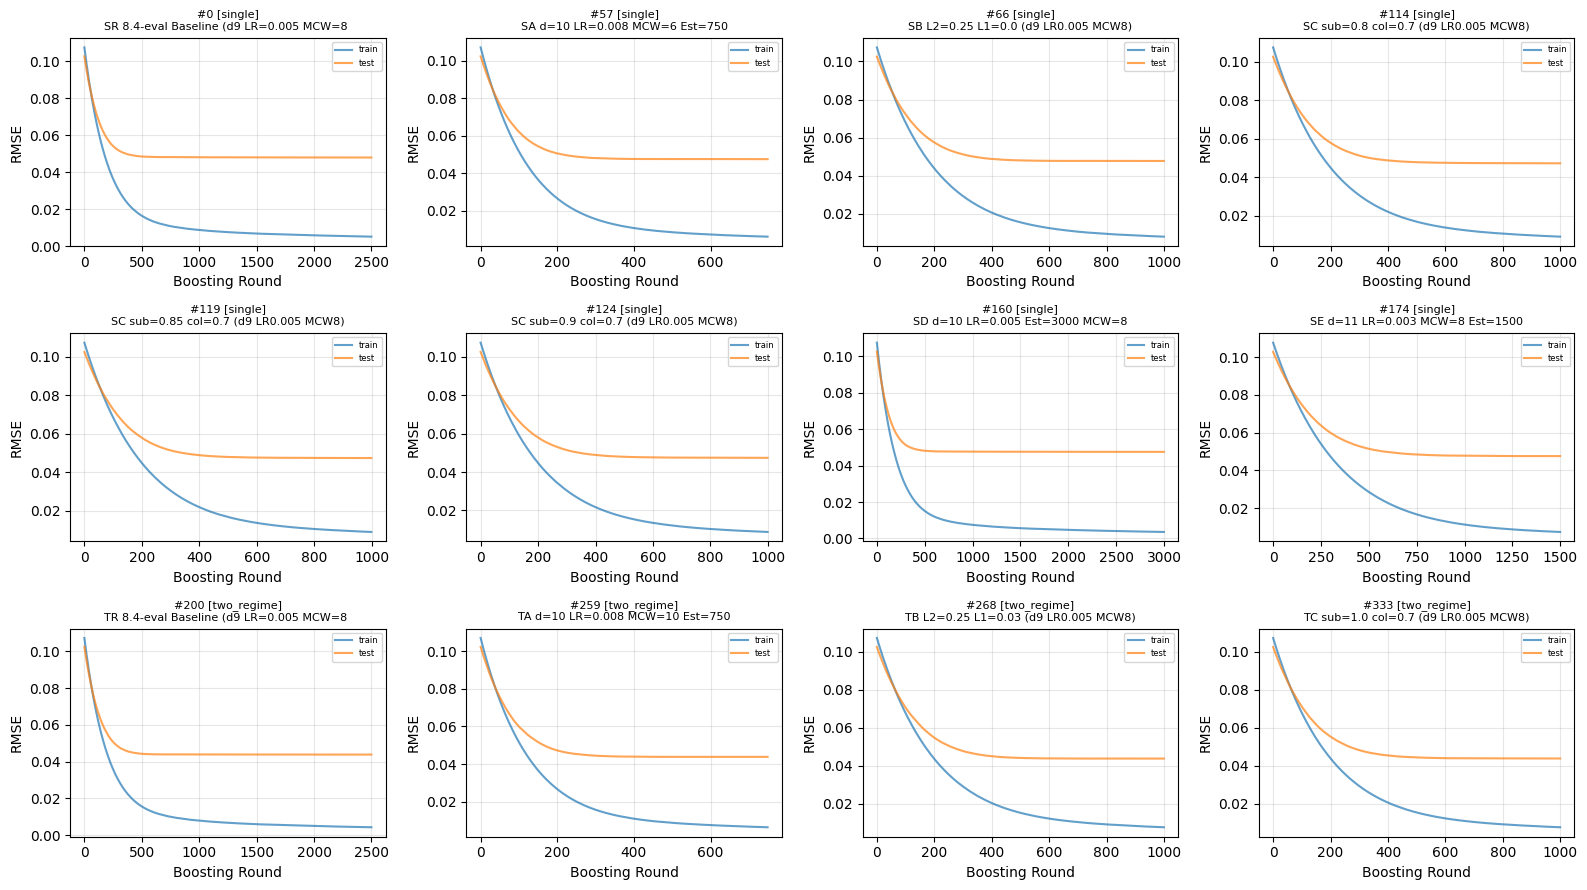

Saved loss_curves.png with 12 panels


In [8]:
# Select 12 models for loss curve visualization
loss_df = pd.read_csv(out_dir / "loss_curves.csv")

# Find top models by track
top_single = summary_df[summary_df["track"] == "single"].sort_values("R2", ascending=False).head(3)["id"].tolist()
top_two = summary_df[summary_df["track"] == "two_regime"].sort_values("R2", ascending=False).head(3)["id"].tolist()
selected_ids = [0, 200] + top_single + top_two

# Add group bests (best per group from each track)
for track_prefix in ["S", "T"]:
    for group in ["A", "B", "C", "D", "E"]:
        gname = track_prefix + group
        best = summary_df[summary_df["group"] == gname].sort_values("R2", ascending=False)
        if len(best):
            selected_ids.append(int(best.iloc[0]["id"]))

selected_ids = sorted(set(selected_ids))[:12]
n_plots = len(selected_ids)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, mid in enumerate(selected_ids):
    ax = axes[i]
    train_col = f"train_loss_model_{mid}"
    test_col = f"test_loss_model_{mid}"
    if train_col in loss_df.columns and test_col in loss_df.columns:
        train_vals = loss_df[train_col].dropna()
        test_vals = loss_df[test_col].dropna()
        if len(train_vals) and len(test_vals):
            ax.plot(train_vals, label="train", alpha=0.7)
            ax.plot(test_vals, label="test", alpha=0.7)
    cfg = next((c for c in MODELS_CONFIG if c["id"] == mid), None)
    label = cfg["name"] if cfg else f"Model {mid}"
    track_label = cfg.get("track", "?") if cfg else "?"
    ax.set_title(f"#{mid} [{track_label}]\n{label[:40]}", fontsize=8)
    ax.set_xlabel("Boosting Round")
    ax.set_ylabel("RMSE")
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(out_dir / "loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved loss_curves.png with {n_plots} panels")


# Section 9: R² by Year & Residual Plots

Visual diagnostics: grouped bar chart comparing overall and per-year R² for top models across both tracks, and residual scatter plots for the best overall model from each track.


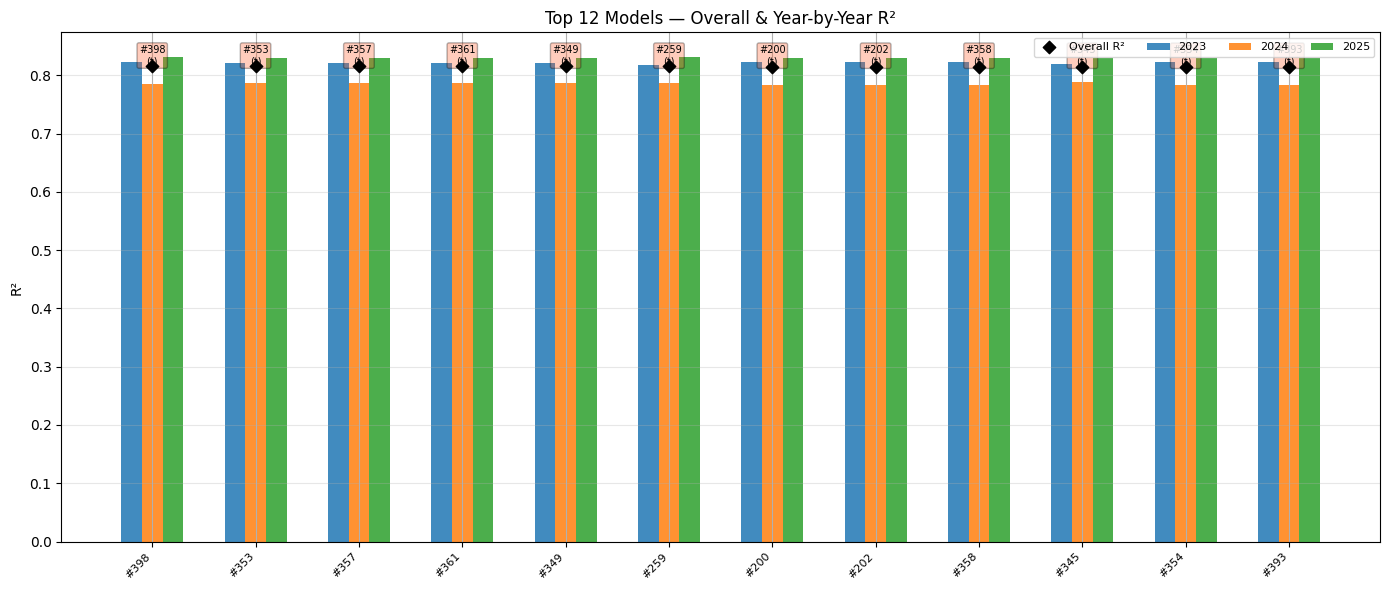

Saved r2_by_year.png


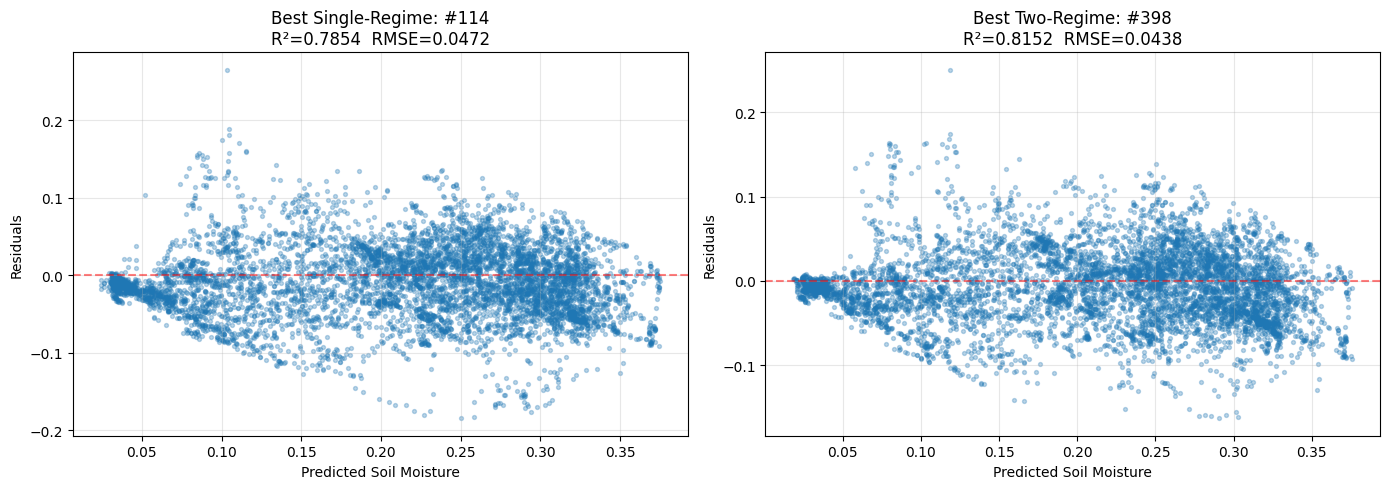

Saved residuals_comparison.png


In [9]:
# --- R2 by Year Bar Chart ---
top12 = summary_df.sort_values("R2", ascending=False).head(12)
top12_ids = top12["id"].values

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top12_ids))
width = 0.2
colors = {"single": "#2196F3", "two_regime": "#FF5722"}

for i, year in enumerate([2023, 2024, 2025]):
    year_data = []
    for mid in top12_ids:
        row = metrics_by_year_df[(metrics_by_year_df["id"] == mid) & (metrics_by_year_df["year"] == year)]
        year_data.append(row["R2"].values[0] if len(row) else float("nan"))
    bars = ax.bar(x + i * width - width, year_data, width, label=f"{year}", alpha=0.85)

# Add overall R² as a scatter
overall_r2 = top12["R2"].values
ax.scatter(x, overall_r2, color="black", marker="D", s=40, zorder=5, label="Overall R²")

track = top12["track"].values
for i, (mid, t) in enumerate(zip(top12_ids, track)):
    color = colors.get(t, "gray")
    ax.annotate(f"#{mid}\n({t[0]})", (x[i], overall_r2[i]), fontsize=7, ha="center", va="bottom",
                bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.3))

ax.set_xticks(x)
ax.set_xticklabels([f"#{mid}" for mid in top12_ids], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("R²")
ax.set_title("Top 12 Models — Overall & Year-by-Year R²")
ax.legend(fontsize=8, ncol=4)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(out_dir / "r2_by_year.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved r2_by_year.png")

# --- Residual Plots ---
# Best single-regime model
best_single = summary_df[summary_df["track"] == "single"].sort_values("R2", ascending=False).iloc[0]
best_two = summary_df[summary_df["track"] == "two_regime"].sort_values("R2", ascending=False).iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, best_row, title in zip(axes,
    [best_single, best_two],
    [f"Best Single-Regime: #{int(best_single['id'])}", f"Best Two-Regime: #{int(best_two['id'])}"]):
    mid = int(best_row["id"])
    preds = test_predictions_df[f"pred_{mid}"].values
    residuals = y_test - preds
    ax.scatter(preds, residuals, alpha=0.3, s=8)
    ax.axhline(y=0, color="red", linestyle="--", alpha=0.5)
    ax.set_xlabel("Predicted Soil Moisture")
    ax.set_ylabel("Residuals")
    ax.set_title(f"{title}\nR²={best_row['R2']:.4f}  RMSE={best_row['RMSE']:.4f}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir / "residuals_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved residuals_comparison.png")


# Section 10: Leaderboard & SOTA Check

Save separate leaderboards for single-regime, two-regime, and overall top-20. Compare against derived_8.4-eval-1.1 baselines to determine whether hyperparameter tuning yields improvements over the reference configurations.


In [10]:
# Save leaderboard CSVs
for track_filter, suffix in [("single", "single"), ("two_regime", "two_regime"), (None, "overall")]:
    df_filtered = summary_df.copy()
    if track_filter is not None:
        df_filtered = df_filtered[df_filtered["track"] == track_filter]
    top20 = df_filtered.sort_values("R2", ascending=False).head(20)
    out_path = out_dir / f"leaderboard_top20_{suffix}.csv"
    top20.to_csv(out_path, index=False)
    print(f"Saved {out_path} ({len(top20)} entries)")

# Overall top-20
print("\n" + "=" * 80)
print("FINAL LEADERBOARD — TOP 20 OVERALL")
print("=" * 80)
top20_overall = summary_df.sort_values("R2", ascending=False).head(20)
display_cols = ["id", "group", "track", "Configuration", "R2", "RMSE", "MAE", "Train Time (s)"]
print(top20_overall[display_cols].to_string(index=False, formatters={
    "R2": "{:,.4f}".format, "RMSE": "{:,.4f}".format,
    "MAE": "{:,.4f}".format, "Train Time (s)": "{:,.2f}".format,
}))

# Compare vs 8.4-eval baselines
best_overall_r2 = summary_df["R2"].max()
best_single_r2 = summary_df[summary_df["track"] == "single"]["R2"].max()
best_two_r2 = summary_df[summary_df["track"] == "two_regime"]["R2"].max()

print(f"\n{'=' * 60}")
print("SOTA COMPARISON")
print(f"{'=' * 60}")
print(f"{'Metric':40s} {'R²':>10s}")
print(f"{'-' * 50}")
print(f"{'8.4-eval Global Baseline (54 Backbone)':40s} {EVAL_11_GLOBAL_BASELINE_R2:>10.5f}")
print(f"{'8.4-eval Clustering Winner (c0=0, c1=10)':40s} {EVAL_11_CLUSTERING_WINNER_R2:>10.5f}")
print(f"{'Best Single-Regime (this sweep)':40s} {best_single_r2:>10.5f}")
print(f"{'Best Two-Regime (this sweep)':40s} {best_two_r2:>10.5f}")
print(f"{'Best Overall (this sweep)':40s} {best_overall_r2:>10.5f}")

delta_single = best_single_r2 - EVAL_11_GLOBAL_BASELINE_R2
delta_two = best_two_r2 - EVAL_11_CLUSTERING_WINNER_R2
print(f"{'Δ Best Single vs Global Baseline':40s} {delta_single:>+10.5f}")
print(f"{'Δ Best Two vs Clustering Winner':40s} {delta_two:>+10.5f}")

# Best config details
best_cfg = summary_df.loc[summary_df["R2"].idxmax()]
print(f"\nBest Overall Configuration:")
print(f"  ID: {int(best_cfg['id'])}")
print(f"  Name: {best_cfg['Configuration']}")
print(f"  Track: {best_cfg['track']}")
config_dict = next((c for c in MODELS_CONFIG if c["id"] == int(best_cfg["id"])), {})
for k, v in config_dict.items():
    if k not in ("id", "name", "group", "track", "routing"):
        print(f"    {k}: {v}")

print(f"\nExperiment complete. All outputs in: {out_dir}")


Saved /scratch/user/u.rp352032/MDR-Project/notebooks/experiment/derived_8.4-hyperparameters-1.0/leaderboard_top20_single.csv (20 entries)
Saved /scratch/user/u.rp352032/MDR-Project/notebooks/experiment/derived_8.4-hyperparameters-1.0/leaderboard_top20_two_regime.csv (20 entries)
Saved /scratch/user/u.rp352032/MDR-Project/notebooks/experiment/derived_8.4-hyperparameters-1.0/leaderboard_top20_overall.csv (20 entries)

FINAL LEADERBOARD — TOP 20 OVERALL
 id group      track                                                     Configuration     R2   RMSE    MAE Train Time (s)
398    TE two_regime                              TE MCW=9 L2=0.5 L1=0.03 (d9 LR0.005) 0.8152 0.0438 0.0338          28.05
353    TD two_regime                                   TD d=10 LR=0.008 Est=1500 MCW=8 0.8151 0.0438 0.0337          47.35
357    TD two_regime                                   TD d=10 LR=0.008 Est=2000 MCW=8 0.8151 0.0438 0.0337          62.26
361    TD two_regime                                 